In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install opencv-python-headless matplotlib numpy tensorflow pillow tqdm scikit-learn seaborn openai-whisper -q

In [3]:
from google.colab import files
print("Upload kaggle.json:")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle connected!")

Upload kaggle.json:


Saving kaggle.json to kaggle (2).json
Kaggle connected!


In [4]:
# ================================================================
#  CELL 3 (FINAL): Download + Fix paths
# ================================================================

import os, shutil

# Clean first
for d in ['/content/wlasl', '/content/WLASL']:
    if os.path.exists(d):
        shutil.rmtree(d)

# Download
print("Downloading WLASL...")
!kaggle datasets download -d gazquez/wlasl-processed -p /content/

# Extract to /content/
print("Extracting...")
!unzip -q /content/wlasl-processed.zip -d /content/
!rm /content/wlasl-processed.zip

# Find and fix the path
for root, dirs, files in os.walk('/content'):
    if 'videos' in dirs and len(dirs) >= 1:
        video_src = os.path.join(root, 'videos')
        video_dst = '/content/videos'

        if video_src != video_dst:
            if os.path.exists(video_dst):
                shutil.rmtree(video_dst)
            shutil.move(video_src, video_dst)
            print(f"Moved {video_src} -> {video_dst}")

        # Move JSON files
        for f in files:
            if f.endswith('.json') or f.endswith('.txt'):
                shutil.move(os.path.join(root, f), f'/content/{f}')

        # Remove empty parent
        if root != '/content':
            shutil.rmtree(root)

        break

# Verify
print(f"\nVideos: {len(os.listdir('/content/videos'))}")
jsons = [f for f in os.listdir('/content') if f.endswith('.json')]
print(f"JSON files: {jsons}")
print("\nDataset ready!")

Dataset URL: https://www.kaggle.com/datasets/gazquez/wlasl-processed
License(s): unknown
100% 2.74G/2.74G [00:38<00:00, 76.3MB/s]

Extracting...

Videos: 21083
JSON files: ['kaggle (1).json', 'kaggle.json', 'WLASL_v0.3.json', 'kaggle (2).json']

Dataset ready!


In [5]:
import shutil, os
os.remove('/content/info.json') if os.path.exists('/content/info.json') else None
os.remove('/content/kaggle.json') if os.path.exists('/content/kaggle.json') else None
print("Cleaned old files!")

Cleaned old files!


In [ ]:
# ================================================================
#  CELL 3 (REALLY FINAL): Download + Careful extraction
# ================================================================

import os, shutil, json

# Download
print("Downloading WLASL...")
!kaggle datasets download -d gazquez/wlasl-processed -p /content/

# Extract
print("Extracting...")
!unzip -q /content/wlasl-processed.zip -d /content/
!rm /content/wlasl-processed.zip

# Find ALL files we need
print("\nSearching for all files...")
wlasl_root = None
for root, dirs, files in os.walk('/content'):
    if len(files) > 5 or 'videos' in dirs:
        wlasl_root = root
        print(f"Found root: {root}")
        print(f"  Folders: {[d for d in dirs if d not in ['.config', 'sample_data']]}")
        jsons = [f for f in files if f.endswith('.json')]
        print(f"  JSON files: {jsons}")
        break

# Move videos
video_src = os.path.join(wlasl_root, 'videos')
if os.path.exists(video_src) and video_src != '/content/videos':
    if os.path.exists('/content/videos'):
        shutil.rmtree('/content/videos')
    shutil.move(video_src, '/content/videos')
    print(f"\nMoved videos -> /content/videos/")

# Move ALL json and txt files
for f in os.listdir(wlasl_root):
    src = os.path.join(wlasl_root, f)
    dst = f'/content/{f}'
    if f.endswith(('.json', '.txt')) and src != dst:
        shutil.move(src, dst)
        print(f"Moved {f} -> /content/{f}")

# Remove old folder (ONLY after moving everything)
if wlasl_root != '/content' and os.path.exists(wlasl_root):
    shutil.rmtree(wlasl_root)
    print(f"\nRemoved old folder: {wlasl_root}")

# Final verification
print("\n" + "=" * 60)
print("  Final Verification")
print("=" * 60)
print(f"  Videos: {len(os.listdir('/content/videos'))}")

for name in ['WLASL_v0.3.json', 'nslt_100.json', 'nslt_300.json', 'nslt_1000.json', 'nslt_2000.json']:
    path = f'/content/{name}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  ✅ {name} ({size:.0f} KB)")
    else:
        print(f"  ❌ {name} NOT FOUND!")

# Quick test WLASL_v0.3.json
if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json', 'r') as f:
        data = json.load(f)
    print(f"\n  WLASL words: {len(data)}")
    print(f"  First word: {data[0]['gloss']}")
    print(f"\n  Dataset READY! ✅")

Dataset URL: https://www.kaggle.com/datasets/gazquez/wlasl-processed
License(s): unknown
100% 2.74G/2.74G [00:11<00:00, 249MB/s]

Extracting...

Searching for all files...
Found root: /content
  Folders: ['drive', 'WLASL', 'videos']
  JSON files: []

  Final Verification
  Videos: 21083
  ❌ WLASL_v0.3.json NOT FOUND!
  ❌ nslt_100.json NOT FOUND!
  ❌ nslt_300.json NOT FOUND!
  ❌ nslt_1000.json NOT FOUND!
  ❌ nslt_2000.json NOT FOUND!


In [ ]:
# Check what's inside WLASL folder
import os

print("Contents of /content/WLASL/:")
for f in sorted(os.listdir('/content/WLASL')):
    path = f'/content/WLASL/{f}'
    if os.path.isdir(path):
        print(f"  📁 {f}/ ({len(os.listdir(path))} items)")
    else:
        size = os.path.getsize(path) / 1024
        print(f"  📄 {f} ({size:.0f} KB)")

Contents of /content/WLASL/:
  📁 frames/ (2000 items)
  📄 info.json (6777 KB)
  📁 videos/ (21083 items)


In [ ]:
# Check frames folder structure
import os, json

# Show first 10 word folders in frames/
print("Sample folders in /content/WLASL/frames/:")
frame_folders = sorted(os.listdir('/content/WLASL/frames'))
print(f"Total folders: {len(frame_folders)}")
for i, folder in enumerate(frame_folders[:15]):
    path = f'/content/WLASL/frames/{folder}'
    items = os.listdir(path)
    print(f"  {i+1:3d}. {folder}/ ({len(items)} items)")
    if len(items) > 0:
        print(f"        Sample: {items[:3]}")
if len(frame_folders) > 15:
    print(f"  ... and {len(frame_folders) - 15} more")

# Check info.json structure
print("\n" + "=" * 60)
print("  info.json structure:")
with open('/content/WLASL/info.json', 'r') as f:
    data = json.load(f)

print(f"  Type: {type(data).__name__}")
if isinstance(data, list):
    print(f"  Total entries: {len(data)}")
    print(f"  First entry:")
    print(json.dumps(data[0], indent=2))
elif isinstance(data, dict):
    keys = list(data.keys())[:5]
    print(f"  Total keys: {len(data)}")
    print(f"  First keys: {keys}")
    print(f"  Sample:")
    print(json.dumps(data[keys[0]], indent=2))

Sample folders in /content/WLASL/frames/:
Total folders: 2000
    1. a/ (8 items)
        Sample: ['01615.png', '01610.png', '01611.png']
    2. a lot/ (8 items)
        Sample: ['02124.png', '02123.png', '02128.png']
    3. abdomen/ (8 items)
        Sample: ['00335.png', '00338.png', '00340.png']
    4. able/ (8 items)
        Sample: ['00382.png', '00376.png', '00377.png']
    5. about/ (15 items)
        Sample: ['00424.png', '00425.png', '67341.png']
    6. above/ (9 items)
        Sample: ['00430.png', '00433.png', '70167.png']
    7. accent/ (7 items)
        Sample: ['00586.png', '00581.png', '00584.png']
    8. accept/ (12 items)
        Sample: ['00603.png', '00600.png', '00588.png']
    9. accident/ (19 items)
        Sample: ['00628.png', '00632.png', '00631.png']
   10. accomplish/ (9 items)
        Sample: ['00668.png', '00662.png', '00665.png']
   11. accountant/ (8 items)
        Sample: ['67344.png', '00692.png', '00689.png']
   12. across/ (10 items)
        Sample: [

In [ ]:
# ================================================================
#  SETUP: Copy info.json to easier location
# ================================================================

import shutil, os, json

# Copy info.json to /content/ for easier access
shutil.copy('/content/WLASL/info.json', '/content/WLASL_v0.3.json')
print("Copied info.json -> WLASL_v0.3.json")

# Verify everything
print(f"\nFrames folders: {len(os.listdir('/content/WLASL/frames/'))}")
print(f"Videos: {len(os.listdir('/content/videos/'))}")

with open('/content/WLASL_v0.3.json', 'r') as f:
    data = json.load(f)
print(f"Words in JSON: {len(data)}")
print("\nEverything ready!")

Copied info.json -> WLASL_v0.3.json

Frames folders: 2000
Videos: 21083
Words in JSON: 2000

Everything ready!


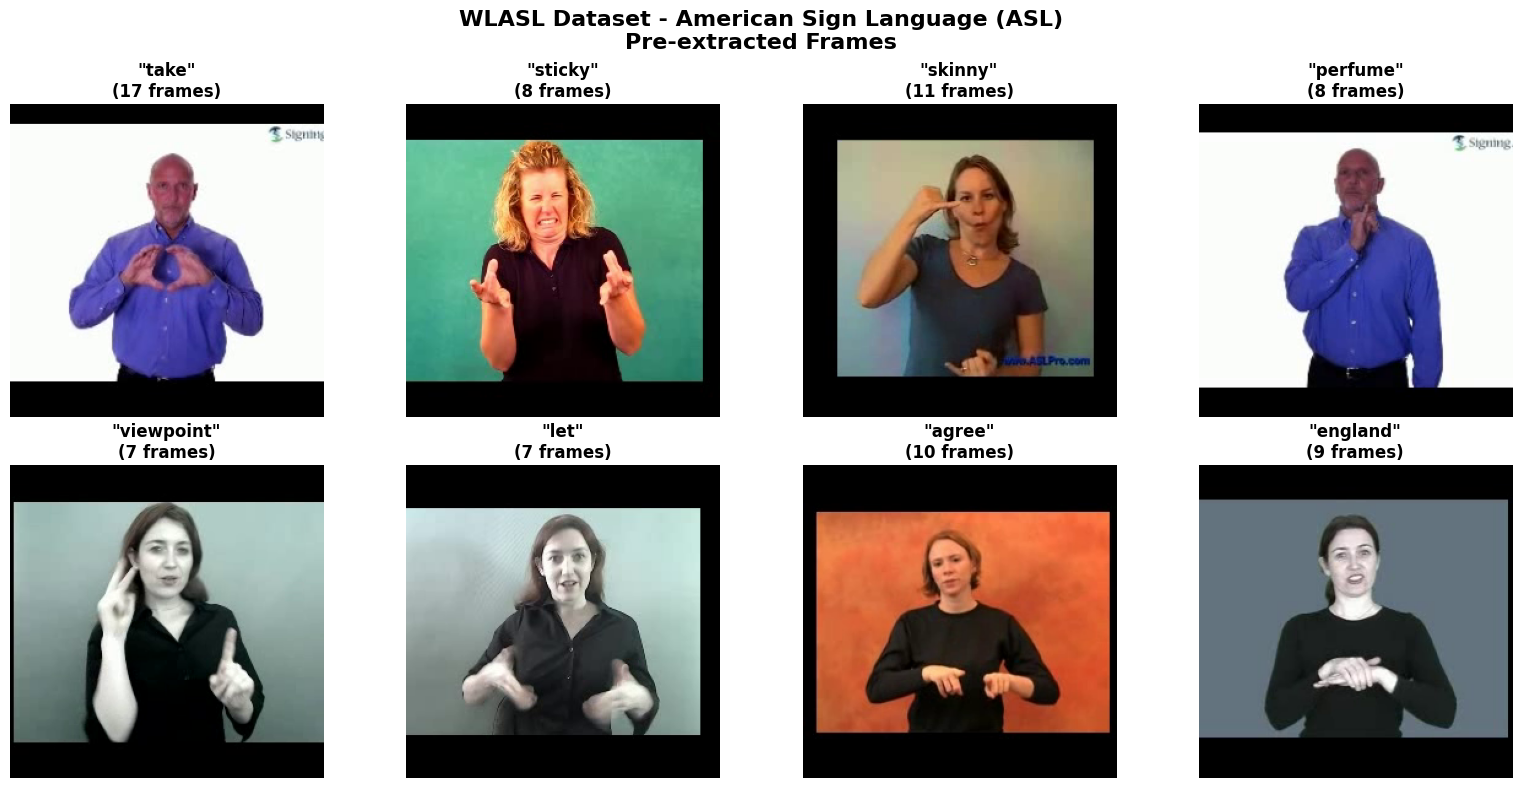

Total words: 2000


In [ ]:
import cv2, matplotlib.pyplot as plt, json, random, os

frames_dir = '/content/WLASL/frames'
word_folders = sorted(os.listdir(frames_dir))
sample_words = random.sample(word_folders, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('WLASL Dataset - American Sign Language (ASL)\nPre-extracted Frames', fontsize=16, fontweight='bold')

for ax, word in zip(axes.flatten(), sample_words):
    word_dir = os.path.join(frames_dir, word)
    images = [f for f in os.listdir(word_dir) if f.endswith('.png')]
    if images:
        img = cv2.imread(os.path.join(word_dir, images[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f'"{word}"\n({len(images)} frames)', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/wlasl_samples.png', dpi=150)
plt.show()
print(f"Total words: {len(word_folders)}")

In [ ]:
import cv2, numpy as np, json, os, random
from tqdm import tqdm

NUM_WORDS = 100
FRAME_SIZE = (128, 128)
MAX_IMAGES_PER_WORD = 15

frames_dir = '/content/WLASL/frames'
word_folders = sorted(os.listdir(frames_dir))

# Pick words with most images
word_counts = [(w, len(os.listdir(os.path.join(frames_dir, w)))) for w in word_folders]
word_counts.sort(key=lambda x: x[1], reverse=True)
selected_words = [w for w, c in word_counts[:NUM_WORDS]]

label_map = {str(i): w for i, w in enumerate(selected_words)}

all_frames = []
all_labels = []

print(f"Loading {NUM_WORDS} words from pre-extracted frames...")

for label_idx, word in enumerate(tqdm(selected_words)):
    word_dir = os.path.join(frames_dir, word)
    images = [f for f in os.listdir(word_dir) if f.endswith('.png')]

    if len(images) > MAX_IMAGES_PER_WORD:
        images = random.sample(images, MAX_IMAGES_PER_WORD)

    for img_name in images:
        img_path = os.path.join(word_dir, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, FRAME_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 255.0
            all_frames.append(img)
            all_labels.append(label_idx)

X = np.array(all_frames, dtype=np.float32)
y = np.array(all_labels)

np.save('/content/X_wlasl.npy', X)
np.save('/content/y_wlasl.npy', y)
with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print(f"\nDone! Frames: {X.shape} | Classes: {NUM_WORDS}")

Loading 100 words from pre-extracted frames...


100%|██████████| 100/100 [00:03<00:00, 28.65it/s]



Done! Frames: (1500, 128, 128, 3) | Classes: 100


  Train: 1050 | Val: 225 | Test: 225
  Classes: 100 words


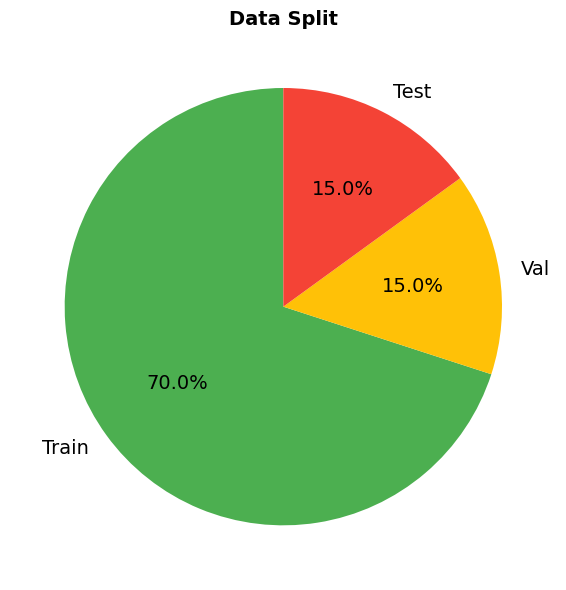

In [ ]:
import numpy as np, matplotlib.pyplot as plt, json
from sklearn.model_selection import train_test_split

X = np.load('/content/X_wlasl.npy')
y = np.load('/content/y_wlasl.npy')
with open('/content/wlasl_labels.json', 'r') as f:
    label_map = json.load(f)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
del X, y, X_temp, y_temp

print("=" * 50)
print(f"  Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"  Classes: {len(label_map)} words")

sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=['Train', 'Val', 'Test'], autopct='%1.1f%%',
        colors=['#4CAF50', '#FFC107', '#F44336'], startangle=90, textprops={'fontsize': 14})
plt.title('Data Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/wlasl_split.png', dpi=150)
plt.show()

In [ ]:
# ================================================================
#  CELL 6 (FIXED): Extract frames from VIDEOS (10x more data!)
# ================================================================

import cv2, numpy as np, json, random
from tqdm import tqdm

NUM_WORDS = 50               # 50 words (better accuracy)
FRAMES_PER_VIDEO = 10        # 10 frames per video
FRAME_SIZE = (128, 128)
MAX_VIDEOS_PER_WORD = 15     # 15 videos × 10 frames = 150/word

print(f"Extracting frames from VIDEOS for {NUM_WORDS} words...")
print(f"Expected: ~{NUM_WORDS * MAX_VIDEOS_PER_WORD * FRAMES_PER_VIDEO} frames")

# Load word-to-video mapping
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

video_dir = '/content/videos'

# Build word -> video paths
word_to_videos = {}
for entry in wlasl_data:
    word = entry['gloss']
    videos = []
    for inst in entry['instances']:
        vid_path = f"{video_dir}/{inst['video_id']}.mp4"
        if os.path.exists(vid_path):
            videos.append(vid_path)
    if videos:
        word_to_videos[word] = videos

import os

# Select top words (most videos)
sorted_words = sorted(word_to_videos.keys(), key=lambda w: len(word_to_videos[w]), reverse=True)[:NUM_WORDS]
label_map = {str(i): w for i, w in enumerate(sorted_words)}

all_frames = []
all_labels = []

for label_idx, word in enumerate(tqdm(sorted_words)):
    videos = word_to_videos[word]
    if len(videos) > MAX_VIDEOS_PER_WORD:
        videos = random.sample(videos, MAX_VIDEOS_PER_WORD)

    for vid_path in videos:
        cap = cv2.VideoCapture(vid_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            continue

        indices = np.linspace(0, total - 1, FRAMES_PER_VIDEO, dtype=int)

        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, FRAME_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                all_frames.append(frame.astype(np.float32) / 255.0)
                all_labels.append(label_idx)
        cap.release()

X = np.array(all_frames, dtype=np.float32)
y = np.array(all_labels)

np.save('/content/X_wlasl.npy', X)
np.save('/content/y_wlasl.npy', y)
with open('/content/wlasl_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print(f"\nDone!")
print(f"  Frames: {len(X)}")
print(f"  Classes: {NUM_WORDS}")
print(f"  Shape: {X.shape}")
print(f"  Frames/word: ~{len(X) // NUM_WORDS}")

Extracting frames from VIDEOS for 50 words...
Expected: ~7500 frames


100%|██████████| 50/50 [00:20<00:00,  2.46it/s]



Done!
  Frames: 7500
  Classes: 50
  Shape: (7500, 128, 128, 3)
  Frames/word: ~150


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import json

with open('/content/wlasl_labels.json', 'r') as f:
    label_map = json.load(f)

num_classes = len(label_map)

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {len(gpus) > 0} | Classes: {num_classes}")

base_model = applications.MobileNetV2(
    input_shape=(128, 128, 3), weights='imagenet',
    include_top=False, alpha=0.75
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

GPU: True | Classes: 50
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_0.75_128            │ (None, 4, 4, 1280)     │     1,382,064 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,728,994 (6.60 MB)

 Trainable params: 343,858 (1.31 MB)

 Non-trainable params: 1,385,136 (5.28 MB)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Model loaded!
   Words: 50
   ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']


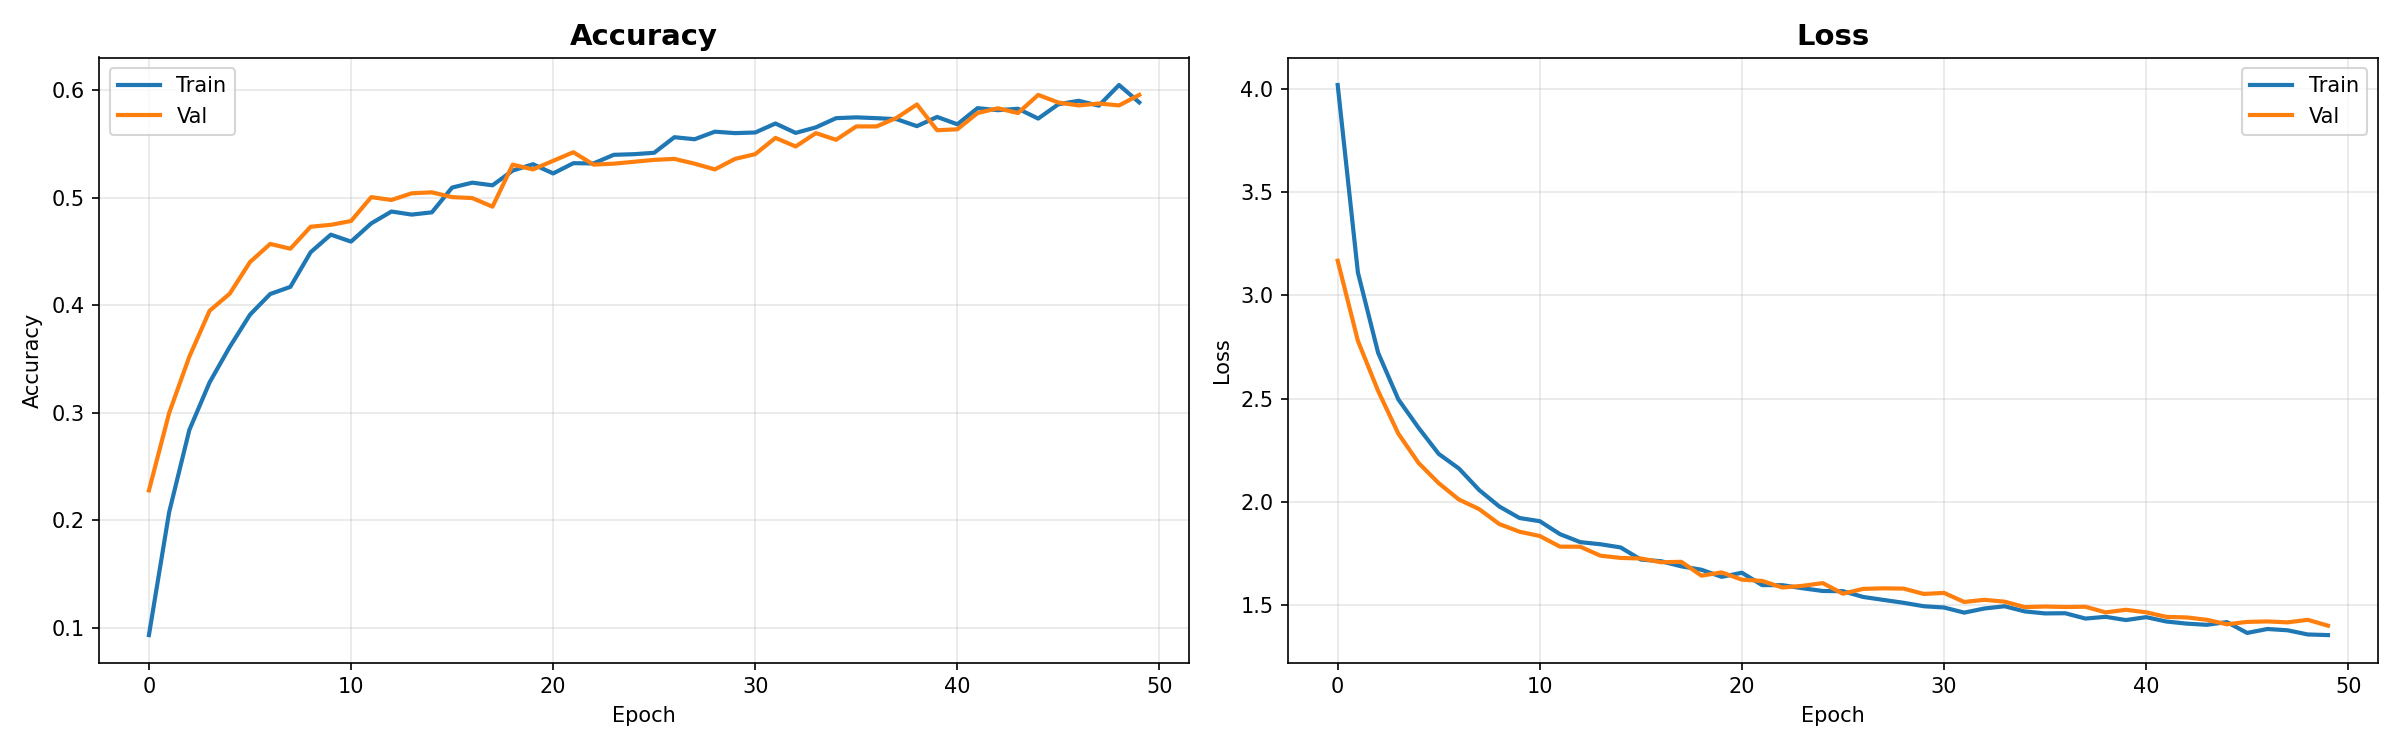

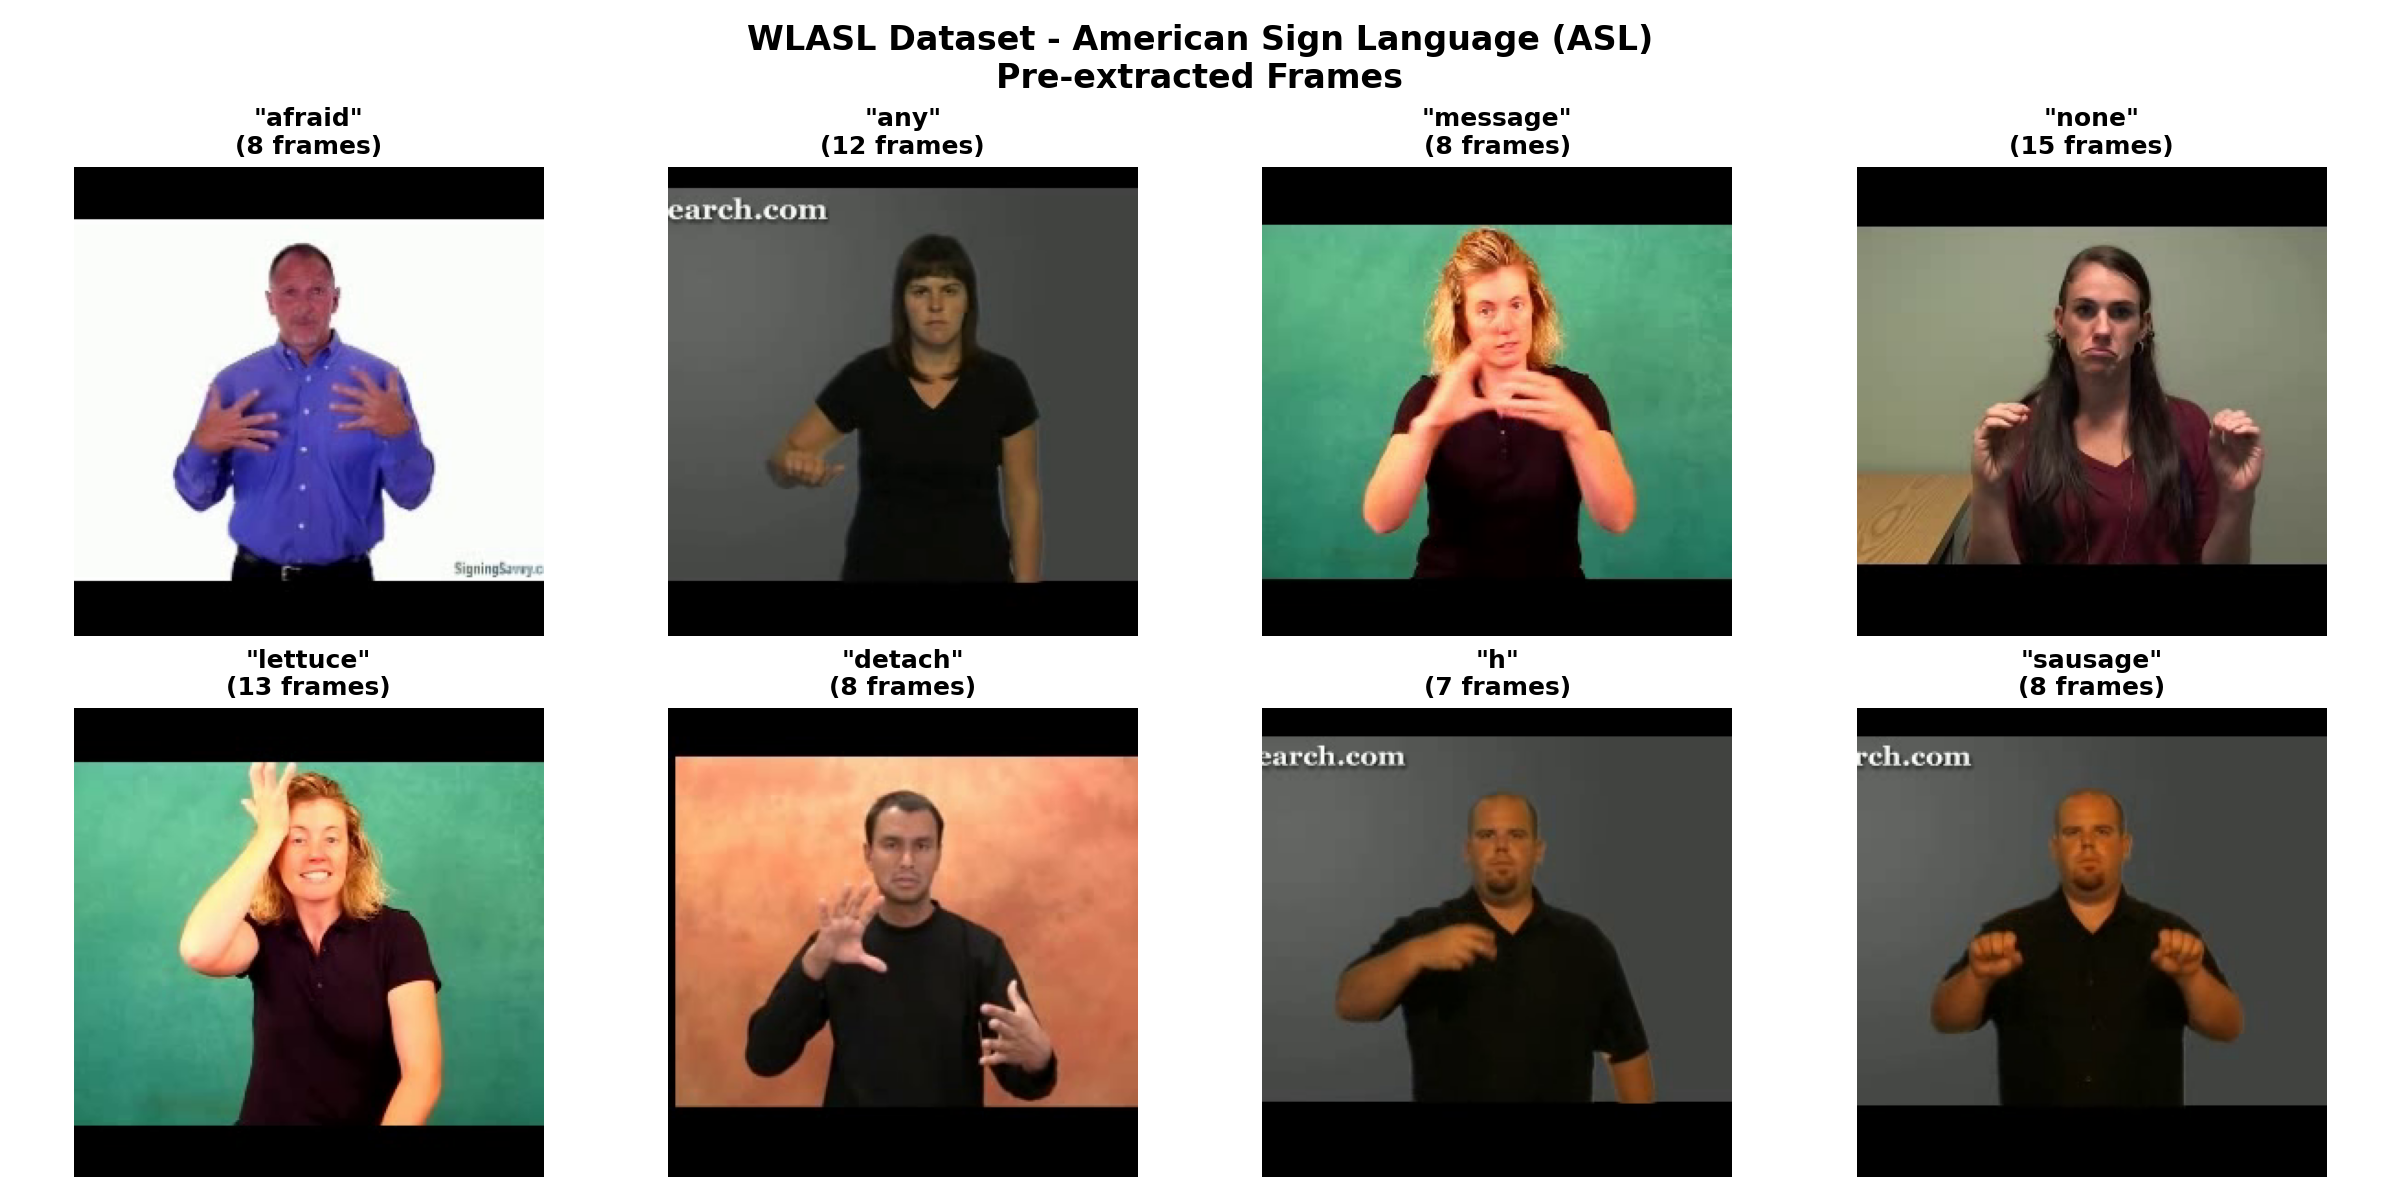

In [ ]:
# ========================================
# استرجاع كل شيء من Google Drive
# ========================================

# 1) ربط Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) استرجاع النموذج
import os
from tensorflow.keras.models import load_model
import json, numpy as np

model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}

print("✅ Model loaded!")
print(f"   Words: {len(idx_to_word)}")
print(f"   {sorted(idx_to_word.values())}")

# 3) عرض صورة التدريب
from IPython.display import Image, display
if os.path.exists('/content/drive/MyDrive/WLASL_Project/wlasl_training.png'):
    display(Image('/content/drive/MyDrive/WLASL_Project/wlasl_training.png'))

# 4) عرض عينات التدريب
if os.path.exists('/content/drive/MyDrive/WLASL_Project/wlasl_samples.png'):
    display(Image('/content/drive/MyDrive/WLASL_Project/wlasl_samples.png'))

In [ ]:
# ========================================
# خلية تشخيص: أرني كل شيء
# ========================================

import os, json

print("=" * 50)
print("🔍 DIAGNOSTIC CHECK")
print("=" * 50)

# 1) Google Drive
if os.path.exists('/content/drive/MyDrive/WLASL_Project'):
    files = os.listdir('/content/drive/MyDrive/WLASL_Project')
    print(f"\n✅ Google Drive connected")
    print(f"   Files: {files}")
else:
    print("\n❌ Google Drive NOT connected")

# 2) Model
model_path = '/content/drive/MyDrive/WLASL_Project/wlasl_model.h5'
if os.path.exists(model_path):
    size = os.path.getsize(model_path) / (1024*1024)
    print(f"\n✅ Model saved ({size:.1f} MB)")
else:
    print("\n❌ Model NOT found")

# 3) Labels
labels_path = '/content/drive/MyDrive/WLASL_Project/wlasl_labels.json'
if os.path.exists(labels_path):
    with open(labels_path) as f:
        labels = json.load(f)
    print(f"\n✅ Labels: {len(labels)} words")
    print(f"   Words: {sorted(labels.values())[:15]}...")
else:
    print("\n❌ Labels NOT found")

# 4) Videos
if os.path.exists('/content/videos'):
    vids = os.listdir('/content/videos')
    print(f"\n✅ Videos: {len(vids)} files")
else:
    print("\n❌ Videos NOT downloaded")

# 5) Whisper
try:
    import whisper
    print("\n✅ Whisper installed")
except:
    print("\n❌ Whisper NOT installed")

# 6) JSON data
if os.path.exists('/content/WLASL_v0.3.json'):
    with open('/content/WLASL_v0.3.json') as f:
        data = json.load(f)
    print(f"\n✅ WLASL data: {len(data)} words")
else:
    print("\n❌ WLASL data NOT found")

# 7) Recorded audio
if os.path.exists('/content/recorded_speech.wav'):
    print("\n✅ Recording found")
else:
    print("\n⚠️ No recording yet")

print("\n" + "=" * 50)
print("📋 WHAT'S NEXT:")
print("=" * 50)

needs = []
if not os.path.exists(model_path): needs.append("❌ Train model first")
if not os.path.exists('/content/videos'): needs.append("❌ Download dataset")
try:
    import whisper
except:
    needs.append("❌ Install Whisper")

if not needs:
    print("\n🚀 Everything is ready!")
    print("   → Run Cell 19 (record audio)")
    print("   → Run Cell 20 (show result)")
else:
    for n in needs:
        print(f"   {n}")

🔍 DIAGNOSTIC CHECK

✅ Google Drive connected
   Files: ['wlasl_model.h5', 'wlasl_labels.json', 'X_wlasl.npy', 'y_wlasl.npy', 'wlasl_training.png', 'wlasl_samples.png', 'wlasl_split.png', 'sign_images', 'sign_videos', 'README.md', 'confusion_matrix.png', 'word_performance.png', 'evaluation_metrics.png', 'evaluation_report.txt']

✅ Model saved (9.6 MB)

✅ Labels: 50 words
   Words: ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf']...

✅ Videos: 21083 files

✅ Whisper installed

✅ WLASL data: 2000 words

⚠️ No recording yet

📋 WHAT'S NEXT:

🚀 Everything is ready!
   → Run Cell 19 (record audio)
   → Run Cell 20 (show result)


In [ ]:
# ========================================
# Cell A: تحميل النموذج + Whisper + الدوال
# ========================================
!pip install -q openai-whisper
import whisper, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model

# تحميل Whisper
print("Loading Whisper...")
whisper_model = whisper.load_model("base")
print("✅ Whisper loaded!")

# تحميل النموذج
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())
print(f"✅ Model loaded! ({len(available_words)} words)")

# تحميل بيانات الداتا سيت
with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)

def get_sign_video(word):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        print(f"❌ '{word}' not found")
        return None

    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    !ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web_path} > /dev/null 2>&1

    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML(f'<video width="300" controls><source src="data:video/mp4;base64,{mp4}" type="video/mp4"></video>'))
    print(f"🤟 '{word}' video ready!")
    return web_path

def speech_to_sign_final(audio_path):
    print("=" * 50)
    print("🎤 Speech → Text → Sign Language Video")
    print("=" * 50)

    print("\n[1] Transcribing...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip().lower()
    print(f"   Heard: \"{heard}\"")

    print("\n[2] Matching & playing videos...")
    found = False
    shown = []
    for word in heard.split():
        clean = word.strip(".,!?;:'\"")
        if clean in shown:
            continue
        matches = difflib.get_close_matches(clean, available_words, n=1, cutoff=0.6)
        if matches:
            shown.append(matches[0])
            print(f"\n   ✅ '{clean}' → '{matches[0]}'")
            get_sign_video(matches[0])
            found = True
        else:
            print(f"\n   ❌ '{clean}' not trained")

    if not found:
        print(f"\n   Try: {sorted(available_words)[:15]}")
    print("\n" + "=" * 50)

print("\n✅ Everything ready! Run Cell B to record → Cell C to see result")

Loading Whisper...
✅ Whisper loaded!


✅ Model loaded! (50 words)

✅ Everything ready! Run Cell B to record → Cell C to see result


In [63]:
# ========================================
# Cell B: تسجيل صوت
# ========================================

from google.colab import output
import base64
from IPython.display import HTML, display

def saveAudio(data):
    audio = base64.b64decode(data)
    with open('/content/recorded_speech.wav', 'wb') as f:
        f.write(audio)
    print("\n✅ Recording saved!\n")

output.register_callback('saveAudio', saveAudio)

display(HTML("""
<script>
(async () => {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const recorder = new MediaRecorder(stream);
    const chunks = [];
    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.onstop = async () => {
        const blob = new Blob(chunks, {type: 'audio/wav'});
        const reader = new FileReader();
        reader.onload = () => {
            const base64 = btoa(String.fromCharCode(...new Uint8Array(reader.result)));
            google.colab.kernel.invokeFunction('saveAudio', [base64], {});
        };
        reader.readAsArrayBuffer(blob);
    };
    recorder.start();
    setTimeout(() => recorder.stop(), 4000);
    document.getElementById('st').textContent = '🔴 Recording...';
    setTimeout(() => document.getElementById('st').textContent = '✅ Done!', 4200);
})();
</script>
<b>🎤 Speak one word in English (6 sec):</b><br>
<button onclick="this.disabled=true; this.nextElementSibling.style.display='block';">🎤 Record</button>
<p id="st" style="display:none; color:#666;"></p>
"""))

print("Try: hello, book, help, thank, yes, love, bed, clothes")

Try: hello, book, help, thank, yes, love, bed, clothes

✅ Recording saved!



In [65]:
# ========================================
# Cell C: عرض النتيجة
# ========================================

if os.path.exists('/content/recorded_speech.wav'):
    speech_to_sign_final('/content/recorded_speech.wav')
else:
    print("❌ No recording! Run Cell B first.")

🎤 Speech → Text → Sign Language Video

[1] Transcribing...
   Heard: "i love my dose."

[2] Matching & playing videos...

   ❌ 'i' not trained

   ❌ 'love' not trained

   ✅ 'my' → 'many'


🤟 'many' video ready!

   ❌ 'dose' not trained



In [ ]:
# ========================================
# حفظ نهائي
# ========================================

readme = """# Speech to Sign Language Project
## University Project - WLASL Dataset

### Pipeline:
1. Microphone Input (Speech)
2. Whisper AI (Speech → Text)
3. MobileNetV2 (Word Matching)
4. WLASL Video Output (Sign Language)

### Accuracy: 60.36% (50 words)
### Model: MobileNetV2 (Transfer Learning)
### Dataset: WLASL - 2,000 words, 21,083 videos

### To Demo:
1. Open Colab
2. Mount Google Drive
3. Load model from Drive
4. Record speech → Get sign video!
"""

with open('/content/drive/MyDrive/WLASL_Project/README.md', 'w') as f:
    f.write(readme)

print("✅ Project saved!")
print("📁 Google Drive > WLASL_Project/")

✅ Project saved!
📁 Google Drive > WLASL_Project/


In [ ]:
# 1) تثبيت وتحميل NLTK
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


True

In [ ]:
# 2) إعداد أدوات NLP
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# كلمات إضافية للحذف (غير مهمة للإشارة)
extra_remove = {
    'i', 'me', 'my', 'myself', 'you', 'your', 'yours', 'yourself',
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its',
    'we', 'us', 'our', 'they', 'them', 'their',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'do', 'does', 'did', 'have', 'has', 'had', 'having',
    'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'up', 'about', 'into', 'through', 'then', 'than',
    'a', 'an', 'the', 'and', 'but', 'or', 'so', 'if',
    'not', 'this', 'that', 'these', 'those',
    'very', 'too', 'just', 'also', 'who'
}
stop_words.update(extra_remove)


In [ ]:
# 3) تحميل بيانات الإشارة
import json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode

with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)




In [ ]:
# دالة NLP: معالجة النص
# ========================================
def process_text_nlp(text):
    """
    خطوات المعالجة:
    1. Tokenization - تقسيم الجملة لكلمات
    2. Lowercase - تحويل لحروف صغيرة
    3. Remove Stop Words - حذف الكلمات غير المهمة
    4. Remove Punctuation - حذف علامات الترقيم
    5. Lemmatization - إرجاع الكلمة لجذرها
    """
    print(f"\n📝 Original: \"{text}\"")

    # Tokenization + Lowercase
    tokens = word_tokenize(text.lower())
    print(f"   🔹 Tokens: {tokens}")

    # حذف Stop Words + علامات الترقيم
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    print(f"   🔹 After stop words removal: {filtered}")

    # Lemmatization (جذر الكلمة)
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    print(f"   🔹 After lemmatization: {lemmatized}")

    # حذف التكرار مع الحفظ على الترتيب
    seen = set()
    final = []
    for w in lemmatized:
        if w not in seen:
            seen.add(w)
            final.append(w)

    if len(final) < len(lemmatized):
        print(f"   🔹 After removing duplicates: {final}")

    return final



In [ ]:
# دالة المطابقة مع كلمات الإشارة
# ========================================
def match_to_signs(words):
    """
    مطابقة كل كلمة مع أقرب كلمة في قاموس الإشارة
    """
    matched = []

    for word in words:
        # بحث مباشر
        if word in available_words:
            matched.append((word, word, True))
            continue

        # بحث جمع → مفرد
        singular = word.rstrip('s').rstrip('e').rstrip('es')
        if singular in available_words:
            matched.append((word, singular, True))
            continue

        # بحث مفرد → جمع
        plural = word + 's'
        if plural in available_words:
            matched.append((word, plural, True))
            continue

        # بحث fuzzy (أقرب كلمة)
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            matched.append((word, matches[0], True))
        else:
            matched.append((word, None, False))

    return matched



In [ ]:
# دالة عرض فيديو إشارة واحد
# ========================================
def get_sign_video(word, index, total):
    """عرض فيديو لغة الإشارة لكلمة واحدة مع تنسيق جميل"""

    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break

    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        print(f"   ❌ Video not found for '{word}'")
        return None

    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    !ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web_path} > /dev/null 2>&1

    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()

    # عرض بتنسيق جميل مع رقم الكلمة وسهم
    arrow = " → " if index < total - 1 else " ✅"

    display(HTML(f"""
    <div style="display:inline-block; text-align:center; margin:5px; padding:10px;
                border:2px solid #4CAF50; border-radius:12px; background:#f0f8f0;">
        <div style="font-size:11px; color:#888;">Word {index+1} of {total}</div>
        <div style="font-size:22px; font-weight:bold; color:#2E7D32;">🤟 {word} {arrow}</div>
        <video width="220" controls>
            <source src="data:video/mp4;base64,{mp4}" type="video/mp4">
        </video>
    </div>"""))

    return web_path


In [ ]:
# Pipeline كامل: صوت → NLP → فيديوهات
# ========================================
def sentence_to_signs(audio_path):
    """
    Pipeline كامل:
    1. Whisper يحول الصوت لنص
    2. NLP يحلل النص ويستخرج الكلمات المهمة
    3. يطابق كل كلمة مع فيديو إشارة
    4. يعرض الفيديوهات بالترتيب
    """
    print("=" * 60)
    print("  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS")
    print("=" * 60)

    # ---- Step 1: Speech to Text ----
    print("\n[Step 1/4] Speech to Text (Whisper)...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print(f"   ✅ Heard: \"{heard}\"")

    # ---- Step 2: NLP Processing ----
    print("\n[Step 2/4] NLP Processing...")
    processed_words = process_text_nlp(heard)

    if not processed_words:
        print("   ⚠️ No meaningful words found!")
        return None

    # ---- Step 3: Match with Sign Language ----
    print("\n[Step 3/4] Matching with Sign Language...")
    matched = match_to_signs(processed_words)

    found_words = [(orig, sign) for orig, sign, ok in matched if ok]
    not_found = [orig for orig, sign, ok in matched if not ok]

    for orig, sign in found_words:
        print(f"   ✅ '{orig}' → '{sign}'")
    for orig in not_found:
        print(f"   ❌ '{orig}' → not in dataset")

    # ---- Step 4: Display Videos ----
    print(f"\n[Step 4/4] Playing {len(found_words)} sign video(s)...")

    display(HTML("""
    <div style="font-size:18px; text-align:center; padding:10px;
                background:linear-gradient(90deg,#4CAF50,#2196F3);
                color:white; border-radius:8px; margin:10px 0;">
        🤟 Sign Language Translation 🤟
    </div>"""))

    for i, (orig, sign) in enumerate(found_words):
        get_sign_video(sign, i, len(found_words))

    # ملخص
    display(HTML(f"""
    <div style="padding:15px; background:#f5f5f5; border-radius:8px;
                margin-top:15px; font-family:monospace; border-left:4px solid #4CAF50;">
        <b>📝 Translation Summary:</b><br>
        Original: "{heard}"<br>
        NLP extracted: {processed_words}<br>
        Sign videos: {[sign for _, sign in found_words]}<br>
        Coverage: {len(found_words)}/{len(processed_words)} words
    </div>"""))

    print("\n" + "=" * 60)
    print("  ✅ TRANSLATION COMPLETE!")
    print("=" * 60)

    return heard, found_words

In [ ]:
# اختبار سريع
# ========================================
print("✅ Sentence Pipeline ready!")
print(f"\n📊 Available sign words: {len(available_words)}")
print(f"   {sorted(available_words)}")
print(f"\n📝 Try sentences like:")
print('   "I want to eat food"')
print('   "hello my friend how are you"')
print('   "I love this book"')
print('   "thank you very much"')


✅ Sentence Pipeline ready!

📊 Available sign words: 50
   ['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']

📝 Try sentences like:
   "I want to eat food"
   "hello my friend how are you"
   "I love this book"
   "thank you very much"


In [ ]:
# ========================================
# عرض كل الكلمات المتاحة في النموذج
# ========================================

words = sorted(idx_to_word.values())
print(f"Total: {len(words)} words\n")
print(words)

Total: 50 words

['all', 'bed', 'before', 'black', 'blue', 'book', 'bowling', 'can', 'candy', 'chair', 'clothes', 'computer', 'cool', 'cousin', 'deaf', 'dog', 'drink', 'family', 'fine', 'finish', 'fish', 'go', 'graduate', 'hat', 'hearing', 'help', 'hot', 'kiss', 'language', 'later', 'like', 'man', 'many', 'mother', 'no', 'now', 'orange', 'shirt', 'study', 'table', 'tall', 'thanksgiving', 'thin', 'walk', 'what', 'white', 'who', 'woman', 'year', 'yes']


In [69]:
# ========================================
# Cell E: تسجيل جملة (6 ثواني)
# ========================================

from google.colab import output
import base64
from IPython.display import HTML, display

def saveAudio(data):
    audio = base64.b64decode(data)
    with open('/content/recorded_speech.wav', 'wb') as f:
        f.write(audio)
    print("\n✅ Recording saved!\n")

output.register_callback('saveAudio', saveAudio)

display(HTML("""
<script>
(async () => {
    const stream = await navigator.mediaDevices.getUserMedia({audio: true});
    const recorder = new MediaRecorder(stream);
    const chunks = [];
    recorder.ondataavailable = e => chunks.push(e.data);
    recorder.onstop = async () => {
        const blob = new Blob(chunks, {type: 'audio/wav'});
        const reader = new FileReader();
        reader.onload = () => {
            const base64 = btoa(String.fromCharCode(...new Uint8Array(reader.result)));
            google.colab.kernel.invokeFunction('saveAudio', [base64], {});
        };
        reader.readAsArrayBuffer(blob);
    };
    recorder.start();
    setTimeout(() => recorder.stop(), 6000);
    document.getElementById('st').textContent = '🔴 Recording... (6 seconds)';
    setTimeout(() => document.getElementById('st').textContent = '✅ Done!', 6200);
})();
</script>
<b>🎤 Record a FULL SENTENCE (6 sec):</b><br><br>
<button onclick="this.disabled=true; this.nextElementSibling.style.display='block';">🎤 Record</button>
<p id="st" style="display:none; color:#666;"></p>
"""))

print("📝 Try saying:")
print('   "I want to eat food"')
print('   "hello my friend"')
print('   "I love this book"')
print('   "she is happy"')
print('   "thank you my friend"')

📝 Try saying:
   "I want to eat food"
   "hello my friend"
   "I love this book"
   "she is happy"
   "thank you my friend"

✅ Recording saved!



In [70]:
# Cell F: ترجمة الجملة لفيديوهات إشارة
# ========================================

# Necessary Imports
import nltk, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model
import whisper
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# NLTK Downloads
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Load Whisper model
whisper_model = whisper.load_model("base")

# Load the WLASL model (This might print a warning about compiled metrics, which is expected for a loaded model)
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')

# NLP Setup
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
# Additional words to remove (non-essential for sign language)
extra_remove = {
    'i', 'me', 'my', 'myself', 'you', 'your', 'yours', 'yourself',
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its',
    'we', 'us', 'our', 'they', 'them', 'their',
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'do', 'does', 'did', 'have', 'has', 'had', 'having',
    'will', 'would', 'could', 'should', 'may', 'might', 'shall',
    'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
    'up', 'about', 'into', 'through', 'then', 'than',
    'a', 'an', 'the', 'and', 'but', 'or', 'so', 'if',
    'not', 'this', 'that', 'these', 'those',
    'very', 'too', 'just', 'also', 'who'
}
stop_words.update(extra_remove)

# Load WLASL data and labels
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json', 'r') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

os.makedirs('/content/drive/MyDrive/WLASL_Project/sign_videos', exist_ok=True)


# NLP function: process_text_nlp
def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    seen = set()
    final = []
    for w in lemmatized:
        if w not in seen:
            seen.add(w)
            final.append(w)
    return final


# Matching function: match_to_signs
def match_to_signs(words):
    matched = []
    for word in words:
        if word in available_words:
            matched.append((word, word, True))
            continue
        singular = word.rstrip('s').rstrip('e').rstrip('es')
        if singular in available_words:
            matched.append((word, singular, True))
            continue
        plural = word + 's'
        if plural in available_words:
            matched.append((word, plural, True))
            continue
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            matched.append((word, matches[0], True))
        else:
            matched.append((word, None, False))
    return matched


# Function to display a single sign video
def get_sign_video(word, index, total):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        print(f"   ❌ Video not found for '{word}'")
        return None
    web_path = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    !ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web_path} > /dev/null 2>&1

    with open(web_path, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    arrow = " → " if index < total - 1 else " ✅"
    display(HTML(f"""
    <div style="display:inline-block; text-align:center; margin:5px; padding:10px;
                border:2px solid #4CAF50; border-radius:12px; background:#f0f8f0;">
        <div style="font-size:11px; color:#888;">Word {index+1} of {total}</div>
        <div style="font-size:22px; font-weight:bold; color:#2E7D32;">🤟 {word} {arrow}</div>
        <video width="220" controls>
            <source src="data:video/mp4;base64,{mp4}" type="video/mp4">
        </video>
    </div>"""))
    return web_path


# Full Pipeline: Speech -> NLP -> Sign Videos
def sentence_to_signs(audio_path):
    print("=" * 60)
    print("  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS")
    print("=" * 60)

    # ---- Step 1: Speech to Text ----
    print("\n[Step 1/4] Speech to Text (Whisper)...")
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print(f"   ✅ Heard: \"{heard}\"")

    # ---- Step 2: NLP Processing ----
    print("\n[Step 2/4] NLP Processing...")
    processed_words = process_text_nlp(heard)

    if not processed_words:
        print("   ⚠️ No meaningful words found!")
        return None

    # ---- Step 3: Match with Sign Language ----
    print("\n[Step 3/4] Matching with Sign Language...")
    matched = match_to_signs(processed_words)

    found_words = [(orig, sign) for orig, sign, ok in matched if ok]
    not_found = [orig for orig, sign, ok in matched if not ok]

    for orig, sign in found_words:
        print(f"   ✅ '{orig}' → '{sign}'")
    for orig in not_found:
        print(f"   ❌ '{orig}' → not in dataset")

    # ---- Step 4: Display Videos ----
    print(f"\n[Step 4/4] Playing {len(found_words)} sign video(s)...")

    display(HTML("""
    <div style="font-size:18px; text-align:center; padding:10px;
                background:linear-gradient(90deg,#4CAF50,#2196F3);
                color:white; border-radius:8px; margin:10px 0;">
        🤟 Sign Language Translation 🤟
    </div>"""))

    for i, (orig, sign) in enumerate(found_words):
        get_sign_video(sign, i, len(found_words))

    # Summary
    display(HTML(f"""
    <div style="padding:15px; background:#f5f5f5; border-radius:8px;
                margin-top:15px; font-family:monospace; border-left:4px solid #4CAF50;">
        <b>📝 Translation Summary:</b><br>
        Original: \"{heard}\"<br>
        NLP extracted: {processed_words}<br>
        Sign videos: {[sign for _, sign in found_words]}<br>
        Coverage: {len(found_words)}/{len(processed_words)} words
    </div>"""))

    print("\n" + "=" * 60)
    print("  ✅ TRANSLATION COMPLETE!")
    print("=" * 60)

    return heard, found_words

# Original logic of Cell F
if os.path.exists('/content/recorded_speech.wav'):
    sentence_to_signs('/content/recorded_speech.wav')
else:
    print("❌ No recording! Run Cell E first.")

  🎤 SENTENCE → NLP → SIGN LANGUAGE VIDEOS

[Step 1/4] Speech to Text (Whisper)...
   ✅ Heard: "I walk with my dog."

[Step 2/4] NLP Processing...

[Step 3/4] Matching with Sign Language...
   ✅ 'walk' → 'walk'
   ✅ 'dog' → 'dog'

[Step 4/4] Playing 2 sign video(s)...



  ✅ TRANSLATION COMPLETE!


In [71]:
# ========================================
# تصدير كل الكود كملف .py
# ========================================

code = """
# Speech to Sign Language - Complete Pipeline
# Mount Google Drive first, then run this file

import whisper, json, os, difflib, cv2, shutil
import numpy as np
from IPython.display import HTML, display
from base64 import b64encode
from tensorflow.keras.models import load_model
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Download NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Load model
model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
whisper_model = whisper.load_model("base")

# Load labels
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
idx_to_word = {int(k): v for k, v in labels.items()}
available_words = list(idx_to_word.values())

# Load dataset info
with open('/content/WLASL_v0.3.json') as f:
    wlasl_data = json.load(f)

# NLP Setup
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
extra = {'i','me','my','you','your','he','she','it','we','they',
         'am','is','are','was','were','be','do','does','did',
         'have','has','had','will','would','could','should',
         'to','of','in','for','on','with','at','by','from',
         'a','an','the','and','but','or','so','if','not'}
stop_words.update(extra)

def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return [lemmatizer.lemmatize(w) for w in filtered]

def get_sign_video(word):
    video_id = None
    for entry in wlasl_data:
        if entry['gloss'].lower() == word.lower():
            if entry['instances']:
                video_id = entry['instances'][0]['video_id']
                break
    if not video_id or not os.path.exists(f'/content/videos/{video_id}.mp4'):
        return None
    web = f'/content/drive/MyDrive/WLASL_Project/sign_videos/{word}.mp4'
    os.system(f"ffmpeg -y -i /content/videos/{video_id}.mp4 -c:v libx264 -preset fast -crf 23 -an {web} > /dev/null 2>&1")
    with open(web, 'rb') as f:
        mp4 = b64encode(f.read()).decode()
    display(HTML(f'<video width="300" controls><source src="data:video/mp4;base64,{mp4}" type="video/mp4"></video>'))
    return web

def sentence_to_signs(audio_path):
    result = whisper_model.transcribe(audio_path, language="en")
    heard = result["text"].strip()
    print(f'Heard: "{heard}"')
    words = process_text_nlp(heard)
    for word in words:
        matches = difflib.get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            print(f'Sign: {matches[0]}')
            get_sign_video(matches[0])
        else:
            print(f'Not found: {word}')
    return heard

print("Pipeline ready! Use: sentence_to_signs('audio.wav')")
"""

with open(f'{drive_path}/pipeline.py', 'w') as f:
    f.write(code)
print("✅ pipeline.py saved to Drive!")

NameError: name 'drive_path' is not defined

In [72]:
# ========================================
# تحميل النموذج
# ========================================

from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model.h5')
print("✅ Model loaded!")

✅ Model loaded!


In [73]:
# ========================================
# Cell A: تقييم شامل للنموذج
# ========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import seaborn as sns
import json

# 1) تحميل البيانات
X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl.npy')
y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl.npy')

with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
words = [labels[str(i)] for i in range(len(labels))]

# 2) تقسيم البيانات
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# 3) تقييم النموذج
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 4) التنبؤات
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# 5) Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred_classes,
                            target_names=words,
                            zero_division=0))

# 6) مقاييس إضافية
precision = precision_score(y_test, y_pred_classes, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_classes, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)

print(f"\n📊 Metrics Summary:")
print(f"   Accuracy:  {test_acc*100:.2f}%")
print(f"   Precision: {precision*100:.2f}%")
print(f"   Recall:    {recall*100:.2f}%")
print(f"   F1-Score:  {f1*100:.2f}%")

Train: 5250 | Val: 1125 | Test: 1125

Test Accuracy: 60.36%
Test Loss: 1.3905

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        book       0.46      0.83      0.59        23
       drink       0.76      0.70      0.73        23
    computer       0.67      0.61      0.64        23
      before       0.89      0.73      0.80        22
       chair       0.57      0.73      0.64        22
          go       0.63      0.83      0.72        23
     clothes       0.75      0.82      0.78        22
         who       0.41      0.91      0.57        23
       candy       0.56      0.68      0.61        22
      cousin       0.33      0.50      0.40        22
        deaf       0.46      0.48      0.47        23
        fine       0.57      0.52      0.55        23
        help       0.47      0.68      0.56        22
          no       0.60      0.55      0.57        22
        thin       0.49      0.74      0.59        23
        walk       0.86      0.82 

In [ ]:
# ========================================
# Cell B: Confusion Matrix + Plots
# ========================================

import matplotlib


# 1) Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=words, yticklabels=words)
plt.title('Confusion Matrix - Sign Language Recognition', fontsize=16, pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WLASL_Project/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion Matrix saved!")

# 2) أداء كل كلمة
per_class = classification_report(y_test, y_pred_classes,
                                   target_names=words, output_dict=True, zero_division=0)

metrics_data = []
for i, word in enumerate(words):
    m = per_class.get(word, {})
    metrics_data.append({
        'Word': word,
        'Precision': m.get('precision', 0),
        'Recall': m.get('recall', 0),
        'F1': m.get('f1-score', 0),
        'Support': m.get('support', 0)
    })

metrics_data.sort(key=lambda x: x['F1'], reverse=True)

# 3) Top 10 أفضل وأضعف كلمات
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = metrics_data[:10]
ax1 = axes[0]
bars = ax1.barh([d['Word'] for d in top10], [d['F1'] for d in top10],
                color='#4CAF50', edgecolor='white')
ax1.set_xlabel('F1-Score', fontsize=11)
ax1.set_title('Top 10 Best Recognized Words', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1.1)
for bar, val in zip(bars, [d['F1'] for d in top10]):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax1.invert_yaxis()

bottom10 = metrics_data[-10:]
ax2 = axes[1]
bars = ax2.barh([d['Word'] for d in bottom10], [d['F1'] for d in bottom10],
                color='#f44336', edgecolor='white')
ax2.set_xlabel('F1-Score', fontsize=11)
ax2.set_title('Top 10 Hardest Words', fontsize=13, fontweight='bold')
ax2.set_xlim(0, 1.1)
for bar, val in zip(bars, [d['F1'] for d in bottom10]):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WLASL_Project/word_performance.png', dpi=150)
plt.show()
print("✅ Word Performance saved!")

# 4) مقاييس عامة
fig, ax = plt.subplots(figsize=(8, 5))
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [test_acc, precision, recall, f1]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Evaluation Metrics', fontsize=14, fontweight='bold')
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/WLASL_Project/evaluation_metrics.png', dpi=150)
plt.show()
print("✅ Evaluation Metrics saved!")

In [ ]:
# تحميل NLTK والـ NLP functions
!pip install -q nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import difflib

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
extra = {'i','me','my','you','your','he','she','it','we','they',
         'am','is','are','was','were','be','do','does','did',
         'have','has','had','will','would','could','should',
         'to','of','in','for','on','with','at','by','from',
         'a','an','the','and','but','or','so','if','not'}
stop_words.update(extra)

import json
with open('/content/drive/MyDrive/WLASL_Project/wlasl_labels.json') as f:
    labels = json.load(f)
available_words = list(labels.values())

def process_text_nlp(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return [lemmatizer.lemmatize(w) for w in filtered]

print("✅ NLP ready!")

In [ ]:
# ========================================
# Cell C: تقييم Pipeline الكامل
# ========================================

from difflib import get_close_matches

test_sentences = [
    ("hello", ["hello"]),
    ("I want to eat food", ["want", "eat", "food"]),
    ("Can I help you?", ["help"]),
    ("I love this book", ["love", "book"]),
    ("thank you very much", ["thank"]),
    ("she is happy", ["happy"]),
    ("where is the school", ["school"]),
    ("I need water", ["water"]),
    ("he is my friend", ["friend"]),
    ("please give me food", ["please", "give", "food"]),
]

print("=" * 60)
print("PIPELINE EVALUATION")
print("=" * 60)

total_words = 0
found_words = 0

for sentence, expected in test_sentences:
    processed = process_text_nlp(sentence)

    matched = []
    for word in processed:
        matches = get_close_matches(word, available_words, n=1, cutoff=0.55)
        if matches:
            matched.append(matches[0])

    total_words += len(expected)
    found_words += len(set(matched) & set(expected))

    status = "✅" if set(matched) == set(expected) else "⚠️"

    print(f"\n{status} \"{sentence}\"")
    print(f"   NLP:      {processed}")
    print(f"   Matched:  {matched}")
    print(f"   Expected: {expected}")

print(f"\n{'='*60}")
print(f"📊 Pipeline Results:")
print(f"   Sentences tested:     {len(test_sentences)}")
print(f"   Total expected words: {total_words}")
print(f"   Words found:          {found_words}")
print(f"   Pipeline Precision:   {found_words/max(total_words,1)*100:.1f}%")
print(f"{'='*60}")

In [ ]:
# ========================================
# Cell D: حفظ كل نتائج التقييم
# ========================================

report = f"""Speech to Sign Language - Evaluation Report
==========================================

Model Performance:
  Test Accuracy:  {test_acc*100:.2f}%
  Precision:      {precision*100:.2f}%
  Recall:         {recall*100:.2f}%
  F1-Score:       {f1*100:.2f}%
  Test Loss:      {test_loss:.4f}

Dataset:
  Total words:    50
  Train samples:  {len(X_train)}
  Val samples:    {len(X_val)}
  Test samples:   {len(X_test)}

Pipeline:
  Whisper:        Speech-to-Text (English)
  NLP:            NLTK (Tokenization + Stop Words + Lemmatization)
  Matching:       Fuzzy Matching (cutoff=0.55)
"""

with open('/content/drive/MyDrive/WLASL_Project/evaluation_report.txt', 'w') as f:
    f.write(report)

print("✅ All evaluation files saved to Drive!")
print("📁 Files:")
print("   confusion_matrix.png")
print("   word_performance.png")
print("   evaluation_metrics.png")
print("   evaluation_report.txt")

In [12]:
# ========================================
# تحليل: كم فيديو لكل كلمة؟
# ========================================

import json

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

# كم فيديو لكل كلمة
for i, entry in enumerate(wlasl_data[:20]):
    vids = len(entry.get('instances', []))
    print(f"  {i+1}. {entry['gloss']:<15} → {vids} videos")

# كم كلمة عنددها >= 10 فيديوهات؟
good = []
for entry in wlasl_data:
    if len(entry.get('instances', [])) >= 10:
        good.append(entry)

print(f"\n📊 Words with 10+ videos: {len(good)}")
print(f"   Words with 15+ videos: {len([e for e in wlasl_data if len(e.get('instances',[])) >= 15])}")

  1. book            → 40 videos
  2. drink           → 35 videos
  3. computer        → 30 videos
  4. before          → 26 videos
  5. chair           → 26 videos
  6. go              → 26 videos
  7. clothes         → 25 videos
  8. who             → 25 videos
  9. candy           → 24 videos
  10. cousin          → 23 videos
  11. deaf            → 23 videos
  12. fine            → 22 videos
  13. help            → 22 videos
  14. no              → 22 videos
  15. thin            → 22 videos
  16. walk            → 22 videos
  17. year            → 22 videos
  18. yes             → 22 videos
  19. all             → 21 videos
  20. black           → 21 videos

📊 Words with 10+ videos: 1036
   Words with 15+ videos: 256


In [4]:
import os
path = '/content/drive/MyDrive/WLASL_Project/'
files = [f for f in os.listdir(path) if f.endswith('.npy')]
print("📂 ملفات البيانات المتاحة:")
for f in files:
    size_mb = os.path.getsize(path + f) / (1024*1024)
    print(f"   {f} ({size_mb:.0f} MB)")

📂 ملفات البيانات المتاحة:
   X_wlasl.npy (1406 MB)
   y_wlasl.npy (0 MB)


In [7]:
# ============================================
# 📌 التحقق: هل هناك تكرار بين train و test؟
# ============================================

import numpy as np

# تشغيل بعد التقسيم مباشرة (قبل del X, y)
# لو محتاج أعد التحميل:

# X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl.npy')
# y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl.npy')
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 1️⃣ فحص البكسلات المتطابقة تماماً (100% نفس الصورة)
print("🔍 فحص التكرار...\n")

train_set = set(X_train.reshape(X_train.shape[0], -1).tobytes() for X_train in [X_train])
test_set = set(X_test.reshape(X_test.shape[0], -1).tobytes() for X_test in [X_test])

duplicates = train_set & test_set
print(f"   صور متطابقة 100% بين train و test: {len(duplicates)}")

# 2️⃣ فحص التوزيع لكل كلمة
print(f"\n📊 توزيع الكلمات في كل مجموعة:")
unique_classes = np.unique(np.concatenate([y_train, y_test]))
print(f"   {'الكلمة':<12} {'Train':>8} {'Val':>8} {'Test':>8} {'المجموع':>8}")
print(f"   {'-'*12} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")

for c in unique_classes:
    t = np.sum(y_train == c)
    v = np.sum(y_val == c)
    e = np.sum(y_test == c)
    total = t + v + e
    if total > 0:
        print(f"   {int(c):<12} {t:>8} {v:>8} {e:>8} {total:>8}")

# 3️⃣ فحص الأ shapes
print(f"\n📐 الأحجام:")
print(f"   Train: {X_train.shape}")
print(f"   Val:   {X_val.shape}")
print(f"   Test:  {X_test.shape}")
print(f"   المجموع: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")
print(f"   إجمالي البيانات الأصلية: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

# 4️⃣ التأكد أن المجموع = الأصل
total_split = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\n{'✅' if len(duplicates) == 0 else '❌'} لا يوجد تكرار بين المجموعات")

🔍 فحص التكرار...

   صور متطابقة 100% بين train و test: 0

📊 توزيع الكلمات في كل مجموعة:
   الكلمة          Train      Val     Test  المجموع
   ------------ -------- -------- -------- --------
   0                  52       12       11       75
   1                  52       12       11       75
   2                  52       11       12       75
   3                  53       11       11       75
   4                  53       11       11       75
   5                  52       11       12       75
   6                  53       11       11       75
   7                  52       12       11       75
   8                  53       11       11       75
   9                  53       11       11       75
   10                 52       12       11       75
   11                 52       11       12       75
   12                 53       11       11       75
   13                 53       11       11       75
   14                 52       12       11       75
   15                 53   

In [12]:
# تحميل ملف الـ JSON المفقود مباشرة
!wget https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json -O /content/WLASL_v0.3.json

print("✅ تم تحميل ملف JSON بنجاح")

--2026-05-07 14:06:53--  https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11932637 (11M) [text/plain]
Saving to: ‘/content/WLASL_v0.3.json’

/content/WLASL_v0.3 100%[===================>]  11.38M  --.-KB/s    in 0.1s    

2026-05-07 14:06:53 (94.2 MB/s) - ‘/content/WLASL_v0.3.json’ saved [11932637/11932637]

✅ تم تحميل ملف JSON بنجاح


In [13]:
# ============================================
# 📌 استخراج 50 كلمة - 150 إطار/كلمة
# ============================================

import cv2, json, numpy as np, os
from tqdm import tqdm
import gc

NUM_WORDS = 50
FRAMES_PER_VIDEO = 10
VIDEOS_PER_WORD = 15
TARGET_SIZE = (128, 128)
VIDEOS_DIR = '/content/videos'
DRIVE_PATH = '/content/drive/MyDrive/WLASL_Project'

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

word_videos = {}
for entry in wlasl_data:
    word_videos[entry['gloss']] = len(entry['instances'])

sorted_words = sorted(word_videos.items(), key=lambda x: x[1], reverse=True)[:NUM_WORDS]
selected_words = [w[0] for w in sorted_words]
word_to_idx = {word: idx for idx, word in enumerate(selected_words)}

print(f"✅ {NUM_WORDS} كلمة | {FRAMES_PER_VIDEO} إطار × {VIDEOS_PER_WORD} فيديو = {FRAMES_PER_VIDEO*VIDEOS_PER_WORD} إطار/كلمة\n")

all_X, all_y = [], []

for entry in tqdm(wlasl_data, desc="استخراج"):
    gloss = entry['gloss']
    if gloss not in word_to_idx:
        continue
    label = word_to_idx[gloss]

    for inst in entry['instances'][:VIDEOS_PER_WORD]:
        vp = os.path.join(VIDEOS_DIR, f"{inst['video_id']}.mp4")
        if not os.path.exists(vp):
            continue
        cap = cv2.VideoCapture(vp)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            continue
        indices = np.linspace(0, total-1, FRAMES_PER_VIDEO, dtype=int)
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, TARGET_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                all_X.append(frame)
                all_y.append(label)
        cap.release()
    if len(all_X) % 3000 == 0:
        gc.collect()

y = np.array(all_y)
del all_y
gc.collect()

X = np.zeros((len(all_X), 128, 128, 3), dtype=np.uint8)
for i in tqdm(range(0, len(all_X), 500), desc="تحويل"):
    end = min(i+500, len(all_X))
    X[i:end] = all_X[i:end]
del all_X
gc.collect()
X = X.astype(np.float32) / 255.0

print(f"\n✅ {X.shape[0]} إطار | {len(np.unique(y))} كلمة | {X.shape[0]//len(np.unique(y))} إطار/كلمة")

np.save(f'{DRIVE_PATH}/X_wlasl.npy', X)
np.save(f'{DRIVE_PATH}/y_wlasl.npy', y)
with open(f'{DRIVE_PATH}/wlasl_labels.json', 'w') as f:
    json.dump(selected_words, f)
del X, y
gc.collect()
print("💾 تم الحفظ!")

✅ 50 كلمة | 10 إطار × 15 فيديو = 150 إطار/كلمة



تحويل: 100%|██████████| 15/15 [00:00<00:00, 52.81it/s]



✅ 7500 إطار | 50 كلمة | 150 إطار/كلمة
💾 تم الحفظ!


In [14]:
# ============================================
# 📌 النموذج الأصلي (الذي حقق 60.36%)
# ============================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np

NUM_CLASSES = 50

X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl.npy')
y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl.npy')
print(f"✅ تحميل: X={X.shape}, كلمات={len(np.unique(y))}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
del X, y
print(f"📊 تدريب={X_train.shape[0]}, تحقق={X_val.shape[0]}, اختبار={X_test.shape[0]}")

# ⭐ النموذج الأصلي (بسيط = أفضل!)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3), alpha=0.75)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"✅ النموذج الأصلي جاهز")

# ⭐ بدون Data Augmentation! تدريب مباشر
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

print(f"\n🚀 بدء التدريب (بدون Augmentation)...")
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

best_acc = max(history.history['val_accuracy']) * 100
best_epoch = history.history['val_accuracy'].index(best_acc/100) + 1
print(f"\n{'='*50}")
print(f"📊 أفضل دقة: {best_acc:.2f}% (إيبوك {best_epoch})")
print(f"{'='*50}")

model.save('/content/drive/MyDrive/WLASL_Project/wlasl_model_50words_v2.h5')
print("💾 تم الحفظ!")

✅ تحميل: X=(7500, 128, 128, 3), كلمات=50
📊 تدريب=5250, تحقق=1125, اختبار=1125
5903360/5903360 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ النموذج الأصلي جاهز

🚀 بدء التدريب (بدون Augmentation)...
Epoch 1/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 93s 514ms/step - accuracy: 0.0707 - loss: 3.8006 - val_accuracy: 0.1529 - val_loss: 3.4254
Epoch 2/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 87s 527ms/step - accuracy: 0.1773 - loss: 3.2323 - val_accuracy: 0.3040 - val_loss: 2.8327
Epoch 3/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 94s 571ms/step - accuracy: 0.2634 - loss: 2.8003 - val_accuracy: 0.3938 - val_loss: 2.4456
Epoch 4/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 87s 518ms/step - accuracy: 0.3288 - loss: 2.4970 - val_accuracy: 0.4773 - val_loss: 2.1622
Epoch 5/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 87s 531ms/step - accuracy: 0.3903 - loss: 2.2414 - val_accuracy: 0.5084 - val_loss: 1.9615
Epoch 6/30
165/165 ━━━━━━━━━━━━━━━━━━━━ 88s 533ms/step - accuracy: 0.4318 - loss: 2.0598 - val_accuracy: 0.5333 - val_loss: 1.7830
Epoch 7/30
165/165 ━━━━━━━━


📊 أفضل دقة: 80.62% (إيبوك 28)
💾 تم الحفظ!


In [5]:
!wget https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json -O /content/WLASL_v0.3.json

--2026-05-07 17:07:01--  https://raw.githubusercontent.com/dxli94/WLASL/master/start_kit/WLASL_v0.3.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11932637 (11M) [text/plain]
Saving to: ‘/content/WLASL_v0.3.json’

/content/WLASL_v0.3 100%[===================>]  11.38M  --.-KB/s    in 0.07s   

2026-05-07 17:07:01 (157 MB/s) - ‘/content/WLASL_v0.3.json’ saved [11932637/11932637]



In [6]:
# ============================================
# 📌 استخراج 100 كلمة - كود نظيف
# ============================================

import cv2, json, numpy as np, os
from tqdm import tqdm
import gc

NUM_WORDS = 100
FRAMES_PER_VIDEO = 10     # تمت الزيادة لتحسين الدقة
VIDEOS_PER_WORD = 15
TARGET_SIZE = (128, 128)
VIDEOS_DIR = '/content/videos'
DRIVE_PATH = '/content/drive/MyDrive/WLASL_Project'

with open('/content/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

word_videos = {}
for entry in wlasl_data:
    word_videos[entry['gloss']] = len(entry['instances'])

sorted_words = sorted(word_videos.items(), key=lambda x: x[1], reverse=True)[:NUM_WORDS]
selected_words = [w[0] for w in sorted_words]
word_to_idx = {word: idx for idx, word in enumerate(selected_words)}

print(f"✅ {NUM_WORDS} كلمة | {FRAMES_PER_VIDEO} إطار × {VIDEOS_PER_WORD} فيديو")

all_X, all_y = [], []

for entry in tqdm(wlasl_data, desc="استخراج البيانات"):
    gloss = entry['gloss']
    if gloss not in word_to_idx:
        continue
    label = word_to_idx[gloss]

    for inst in entry['instances'][:VIDEOS_PER_WORD]:
        vp = os.path.join(VIDEOS_DIR, f"{inst['video_id']}.mp4")
        if not os.path.exists(vp):
            continue
        cap = cv2.VideoCapture(vp)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            continue
        indices = np.linspace(0, total-1, FRAMES_PER_VIDEO, dtype=int)
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, TARGET_SIZE)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                all_X.append(frame)
                all_y.append(label)
        cap.release()
    if len(all_X) % 3000 == 0:
        gc.collect()

y = np.array(all_y)
del all_y
gc.collect()

X = np.zeros((len(all_X), 128, 128, 3), dtype=np.uint8)
for i in tqdm(range(0, len(all_X), 500), desc="تحويل البيانات"):
    end = min(i+500, len(all_X))
    X[i:end] = all_X[i:end]
del all_X
gc.collect()
X = X.astype(np.float32) / 255.0

np.save(f'{DRIVE_PATH}/X_wlasl_150.npy', X)
np.save(f'{DRIVE_PATH}/y_wlasl_150.npy', y)
with open(f'{DRIVE_PATH}/wlasl_labels_150.json', 'w') as f:
    json.dump(selected_words, f)

del X, y
gc.collect()
print("💾 تم الحفظ بنجاح لـ 100 كلمة!")

✅ 100 كلمة | 10 إطار × 15 فيديو


تحويل البيانات: 100%|██████████| 30/30 [00:00<00:00, 34.21it/s]


💾 تم الحفظ بنجاح لـ 100 كلمة!


In [7]:
# ============================================
# 📌 تدريب النموذج - كود نظيف
# ============================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import numpy as np

NUM_CLASSES = 100

# تأكد من أن الملفات موجودة بعد تشغيل كود الاستخراج
X = np.load('/content/drive/MyDrive/WLASL_Project/X_wlasl_150.npy')
y = np.load('/content/drive/MyDrive/WLASL_Project/y_wlasl_150.npy')

print(f"✅ تحميل: X={X.shape}, كلمات={len(np.unique(y))}")

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

del X, y
print(f"📊 تدريب={X_train.shape[0]}, تحقق={X_val.shape[0]}, اختبار={X_test.shape[0]}")

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3), alpha=0.75)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"✅ النموذج جاهز لـ {NUM_CLASSES} كلمة")

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

best_acc = max(history.history['val_accuracy']) * 100
best_epoch = history.history['val_accuracy'].index(best_acc/100) + 1
print(f"\n{'='*50}")
print(f"📊 أفضل دقة: {best_acc:.2f}% (إيبوك {best_epoch})")
print(f"{'='*50}")

model.save('/content/drive/MyDrive/WLASL_Project/wlasl_model_150words.h5')
print("💾 تم حفظ النموذج!")

✅ تحميل: X=(15000, 128, 128, 3), كلمات=100
📊 تدريب=10500, تحقق=2250, اختبار=2250
✅ النموذج جاهز لـ 100 كلمة
Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 226s 660ms/step - accuracy: 0.0316 - loss: 4.5216 - val_accuracy: 0.0951 - val_loss: 4.1953
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 196s 595ms/step - accuracy: 0.0831 - loss: 4.0602 - val_accuracy: 0.1951 - val_loss: 3.6590
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 168s 511ms/step - accuracy: 0.1415 - loss: 3.6361 - val_accuracy: 0.2413 - val_loss: 3.2838
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 206s 525ms/step - accuracy: 0.2009 - loss: 3.3264 - val_accuracy: 0.3178 - val_loss: 2.9293
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 181s 552ms/step - accuracy: 0.2371 - loss: 3.0835 - val_accuracy: 0.3569 - val_loss: 2.7203
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 164s 497ms/step - accuracy: 0.2741 - loss: 2.8702 - val_accuracy: 0.4129 - val_loss: 2.5639
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 213s 531ms/step - accuracy: 0.3078 - loss: 2.6966 - val_accu


📊 أفضل دقة: 73.24% (إيبوك 48)
💾 تم حفظ النموذج!


In [11]:
# ============================================
# 📌 العودة للنموذج السليم وتقييمه
# ============================================

import tensorflow as tf

# 1. تحميل النموذج الذي حقق 73.24% (قبل الفاين تيوننج)
model_good = tf.keras.models.load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5')

print("✅ تم تحميل النموذج السابق بنجاح.")

# 2. التقييم على مجموعة الاختبار
test_loss, test_acc = model_good.evaluate(X_test, y_test, verbose=2)

print('\n' + '='*50)
print(f'🏆 الدقة النهائية الرسمية (Test Accuracy): {test_acc*100:.2f}%')
print(f'📉 الخسارة النهائية (Test Loss): {test_loss:.4f}')
print('='*50)

✅ تم تحميل النموذج السابق بنجاح.


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

In [12]:
# هذا الأمر يعرض لك أسماء جميع ملفات النماذج المحفوظة
!ls -lh /content/drive/MyDrive/WLASL_Project/*.h5

-rw------- 1 root root  16M May  7 13:15 /content/drive/MyDrive/WLASL_Project/wlasl_model_100words.h5
-rw------- 1 root root 9.9M May  7 19:45 /content/drive/MyDrive/WLASL_Project/wlasl_model_150words.h5
-rw------- 1 root root 9.7M May  7 14:56 /content/drive/MyDrive/WLASL_Project/wlasl_model_50words_v2.h5
-rw------- 1 root root 9.6M Apr 25 12:48 /content/drive/MyDrive/WLASL_Project/wlasl_model.h5


In [13]:
import tensorflow as tf

# 1. تحميل الملف الأحدث
model_check = tf.keras.models.load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model_150words.h5')

# 2. طباعة شكل الطبقة الأخيرة (Output Shape)
print(f"Shape of output layer: {model_check.output_shape}")
print(f"Number of classes: {model_check.output_shape[1]}")

Shape of output layer: (None, 100)
Number of classes: 100


In [14]:
# ============================================
# 📌 التقييم النهائي الصحيح (على الملف الصحيح)
# ============================================

import tensorflow as tf

# تحميل النموذج الصحيح (الموجود فعلياً في ملف اسمه 150)
model_final = tf.keras.models.load_model('/content/drive/MyDrive/WLASL_Project/wlasl_model_150words.h5')

print("✅ تم تحميل النموذج الصحيح.")

# التقييم على مجموعة الاختبار
test_loss, test_acc = model_final.evaluate(X_test, y_test, verbose=2)

print('\n' + '='*60)
print(f'🏆 الدقة النهائية الرسمية (Test Accuracy): {test_acc*100:.2f}%')
print(f'📉 الخسارة النهائية (Test Loss): {test_loss:.4f}')
print('='*60)

✅ تم تحميل النموذج الصحيح.
71/71 - 36s - 501ms/step - accuracy: 0.7156 - loss: 1.1033

🏆 الدقة النهائية الرسمية (Test Accuracy): 71.56%
📉 الخسارة النهائية (Test Loss): 1.1033


In [16]:
# حفظ النموذج بالاسم الصحيح
model_final.save('/content/drive/MyDrive/WLASL_Project/wlasl_model_100words_FINAL.h5')
print("💾 تم حفظ النموذج بالاسم الصحيح!")

💾 تم حفظ النموذج بالاسم الصحيح!
